In [58]:
import matplotlib.pyplot as plt
import numpy as np
from sympy import symbols, diff, integrate, Eq, solve, exp, cos, sin, sqrt

## Задача 1

Дадени са стойности в 5 точки от сигнал от даден акселерометър  
(сензор, измерващ линейно ускорение). Сигналът е периодична функция  
с период **T = 3 ms**.  

Да се намери **тригонометричен полином**, интерполиращ тези точки  
(за целта да се направи подходяща смяна на променливата).  
Да се илюстрира графично, като се визуализират точките и графиката  
на тригонометричния полином в една координатна система  
(в термините на първоначалната променлива).

| t (ms) | 0 | 1 | 1.5 | 2 | 2.5 |
|------|---|---|-----|---|-----|
| ускорение (m/s²) | 0 | 1 | 1.5 | 4 | 2 |

---

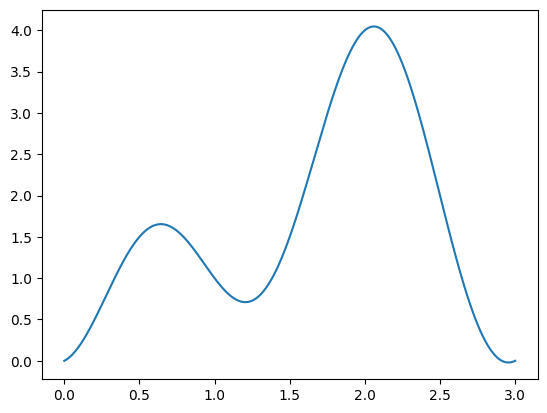

In [59]:
x_values = np.array([0,1,1.5,2,2.5])
transformed_values = (2*np.pi/3)*x_values
y_values = np.array([0,1,1.5,4,2])

def basis_functions(x):
    return np.array([1, np.cos(x), np.sin(x), np.cos(2*x), np.sin(2*x)])

A = np.zeros([5, 5])
for i in range(len(transformed_values)):
    A[i] = basis_functions(transformed_values[i])

sol = np.linalg.solve(A, y_values)
def trig_poly(t):
    x = (2*np.pi/3) * t
    return sol[0] + sol[1] * np.cos(x) + sol[2] * np.sin(x) + sol[3] * np.cos(2 * x) + sol[4] * np.sin(2 * x)

t_axis = np.linspace(0, 3, 300)
plt.plot(t_axis, trig_poly(t_axis))
plt.show()

## Задача 2

По метода на **най-малките квадрати** да се намери подходяща функция,  
която приближава таблицата:

| x | 2 | 4 | 6 | 7 | 10 | 11 | 14 | 17 | 20 |
|---|---|---|---|---|----|----|----|----|----|
| y | 4 | 5 | 6 | 7 | 8 | 8 | 11 | 10 | 12 |

Да се илюстрира графично.

---

In [60]:
x_values = np.array([2 , 4 , 6 , 7 , 10 , 11 , 14 , 17 , 20])
y_values = np.array([4 , 5 , 6 , 7 , 8 , 8 , 11 , 10 , 12])

a, b = symbols('a, b')

def phi(a, b):
    sum = 0
    for i in range (len(x_values)):
        sum+=(a*x_values[i] + b - y_values[i])**2
    return sum

equations = [Eq(diff(phi(a, b), a), 0),
Eq(diff(phi(a, b), b), 0)]
solve(equations)

{a: 52/119, b: 59/17}

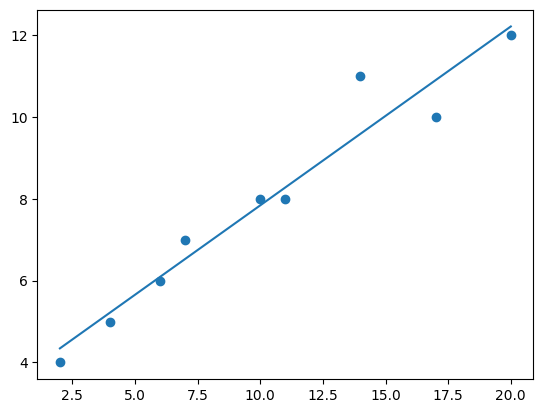

In [61]:
def f(x):
    return 52/119 * x + 59/17

x_axis = np.linspace(x_values[0], x_values[-1], 100)
y_axis = f(x_axis)
plt.plot(x_axis, y_axis)
plt.scatter(x_values, y_values)

## Задача 3

Да се реши **преопределената система**:

\[
\begin{cases}
x + 2y = 1, \\
x - y = 5, \\
3x + 4y = 17.
\end{cases}
\]

---

In [62]:
x,y = symbols('x, y')
def phi(x, y):
    return (x+2*y-1)**2 + (x-y-5)**2+(3*x+4*y-17)**2

equations = [Eq(diff(phi(x, y), x), 0),
Eq(diff(phi(x, y), y), 0)]
solve(equations)

{x: 176/31, y: -13/31}


## Задача 4

По метода на най-малките квадрати да се приближат данните от таблицата
с функция от вида:

$$
y = a \cdot 10^{bx}.
$$

За целта да се използва подходяща линеаризация на модела.
Да се визуализира полученото приближение заедно с данните
в една координатна система.

| x | 0.4 | 0.8 | 1.2 | 1.6 | 2.0 | 2.3 |
|---|-----|-----|-----|-----|-----|-----|
| y | 800 | 975 | 1500 | 1950 | 2900 | 3600 |

---

In [63]:
x_values = np.array([0.4 , 0.8 , 1.2 , 1.6 , 2.0 , 2.3])
y_values = np.array([800 , 975 , 1500 , 1950 , 2900 , 3600])

a, b = symbols('a, b')

def f(a, b, x):
    return a*x+b

def phi(a, b):
    sum = 0
    for i in range (len(x_values)):
        sum+=(f(a,b,x_values[i])-np.log10(y_values[i]))**2
    return sum

equations = [Eq(diff(phi(a, b), a), 0),
Eq(diff(phi(a, b), b), 0)]
sol = solve(equations)
print(sol)

{a: 0.355535711058098, b: 2.73766242833211}


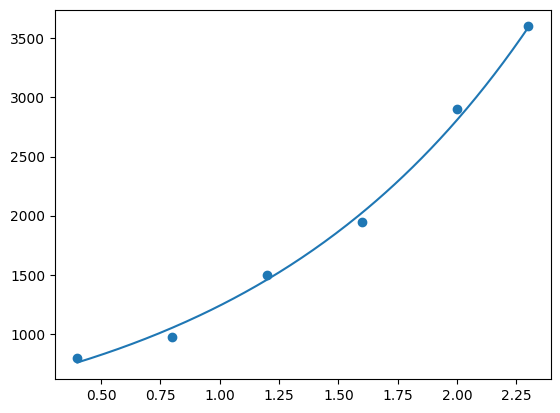

In [64]:
def exp_f(x):
    return 10**(float(sol[a])*x+float(sol[b]))
x_axis = np.linspace(0.4, 2.3, 200)
y_axis = exp_f(x_axis)
plt.plot(x_axis, y_axis)
plt.scatter(x_values, y_values)

## Задача 5

Да се намерят равномерната норма и средноквадратичната норма  
с тегло \(\mu(x) = 1\) за функцията:

$$
f(x) = 1 - x, \quad x \in [0, 3].
$$

Отг.: \( 2;\ \sqrt{3} \).

In [65]:
def f(x):
    return 1-x

print(np.abs(f(3)))

x = symbols('x')
I = integrate((1-x)**2, (x, 0, 3))
print(sqrt(I))

2
sqrt(3)


## Задача 6

Да се намери полином от втора степен на най-добро
средноквадратично приближение в интервала:

$$
\left[0, \frac{\pi}{2}\right]
$$

при тегло \( \mu(x) = 1 \) за функцията:

$$
f(x) = \sin x.
$$

Да се илюстрира графично.
Да се намери средноквадратичното разстояние между полинома и функцията.

---

In [66]:
def f(x):
    return sin(x)

a,b,c,x = symbols('a,b,c,x')

def pol(x, a, b, c):
    return a*x**2 + b*x + c

def phi(x, a, b, c):
    return integrate((f(x)- pol(x, a, b, c))**2, (x, 0 , np.pi/2))

equations = [Eq(diff(phi(x,a,b,c), a), 0), Eq(diff(phi(x,a,b,c), b), 0), Eq(diff(phi(x,a,b,c), c), 0)]
sol = solve(equations)
sol

{a: -0.338240010516360, b: 1.19574506426522, c: -0.0243249469631584}

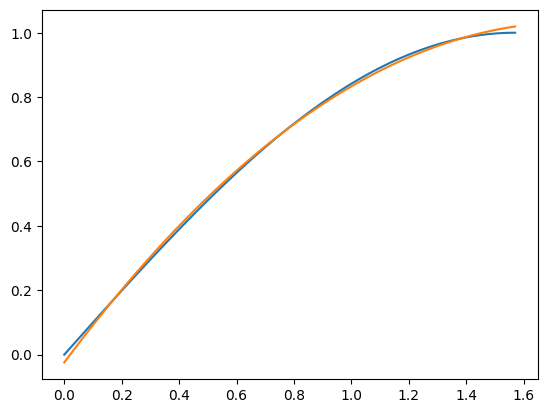

In [67]:
def pol_actual(x):
    return float(sol[a])*x**2 + float(sol[b])*x + float(sol[c])

x_axis = np.linspace(0, np.pi/2, 100)
plt.plot(x_axis, np.sin(x_axis))
plt.plot(x_axis, pol_actual(x_axis))

In [68]:
print(sqrt(phi(x, float(sol[a]), float(sol[b]), float(sol[c]))))

0.0105051059489477


## Задача 7

Да се намери полином от трета степен на най-добро
средноквадратично приближение в интервала [0, 1]
при тегло \( \mu(x) = 1 \) за функцията:

$$
f(x) = e^{x} + 1.
$$

Да се илюстрира графично.
Да се намери средноквадратичното разстояние между полинома и функцията.

---

In [69]:
def f(x):
    return exp(x)+1

a,b,c,d,x = symbols('a,b,c,d,x')

def pol(x, a, b, c,d):
    return a*x**3 + b*x**2 + c*x + d

def phi(a, b, c, d):
    return integrate((f(x)- pol(x, a, b, c, d))**2, (x, 0 , 1))

equations = [Eq(diff(phi(a,b,c,d), a), 0), Eq(diff(phi(a,b,c,d), b), 0), Eq(diff(phi(a,b,c,d), c), 0), Eq(diff(phi(a,b,c,d), d), 0)]
sol = solve(equations)
print(solve(equations))

{a: 27020 - 9940*E, b: -41100 + 15120*E, c: 16800 - 6180*E, d: -1455 + 536*E}


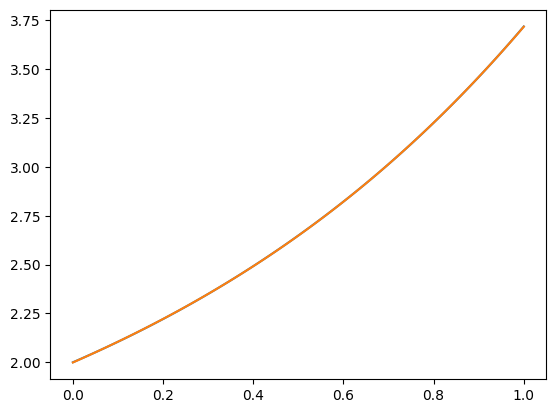

In [70]:
def pol_actual(x):
    return float(sol[a])*x**3 + float(sol[b])*x**2 + float(sol[c])*x + float(sol[d])

x_axis = np.linspace(0, 1, 100)
plt.plot(x_axis, np.exp(x_axis)+1)
plt.plot(x_axis, pol_actual(x_axis))

## Задача 8

Да се пресметне приближено стойността на интеграла:

$$
\int_{-1}^{1} (-x^4 + 1)\,dx
$$

като се използва съставната квадратурна формула на трапеците
с 5 равноотдалечени възела в интервала [-1, 1].

---

In [71]:
n = 5
a = -1
b = 1
x_values = np.linspace(a,b,5)

def f(x):
    return -x**4+1

def trapezoids(n, a, b):
    sum = 0
    for i in range(1, n):
        sum+=f(x_values[i-1]) + f(x_values[i])
    return sum*((b-a)/(2*(n-1)))

print(trapezoids(n,a,b))


1.4375


## Задача 9

Намерете приближено:

$$
\int_{0}^{0.4} f(x)\,dx
$$

използвайки съставната квадратурна формула на Симпсън,
като са известни само следните стойности за функцията:

| x | 0 | 0.1 | 0.2 | 0.3 | 0.4 |
|---|---|-----|-----|-----|-----|
| f(x) | 1 | 8 | 4 | 3.5 | 5 |

---

In [72]:
x_values = np.array([0 , 0.1 , 0.2 , 0.3 , 0.4 ])
y_values = np.array([1 , 8 , 4 , 3.5 , 5])

a = x_values[0]
b = x_values[-1]

sum = 0
n = 5
sum = y_values[0] + y_values[-1]  # first and last

# Add terms with coefficient 4 (odd indices: 1, 3)
for i in range(1, n-1, 2):
    sum += 4 * y_values[i]

# Add terms with coefficient 2 (even indices: 2)
for i in range(2, n-1, 2):
    sum += 2 * y_values[i]

h = (b-a)/(6*(n-1))
print(sum*h)

1.0


## Задача 10

Нека:

$$
f(x) = 1 - \cot x.
$$

Да се намери n, така че n-тата съставна квадратурна формула
на правоъгълниците / трапеците / Симпсън да приближава:

$$
\int_{-2}^{-1} f(x)\,dx
$$

с грешка не по-голяма от:

$$
\varepsilon = 10^{-5}.
$$

Да се пресметне това приближение.

---

In [73]:
def f(x):
    return 1- (1/np.tan(x))

a = -2
b = -1
eps = 10**(-5)

def rectangle_error():
    max_for_f = 1.7
    res = max_for_f * (b-a)**3 / 24
    return np.ceil(np.sqrt(res/eps))

print(rectangle_error()) #85

def trapezoid_error():
    max_for_f = 1.7
    res = -max_for_f*(b-a)**3 / 12
    return np.ceil(np.sqrt(np.abs(res/eps)))

print(trapezoid_error()) #120

def simpson_error():
    max_for_f = 40
    res = -max_for_f*(b-a)**5 / 2880
    return np.ceil(np.sqrt(np.sqrt(np.abs(res/eps))))

print(simpson_error()) #7

85.0
120.0
7.0


## Задача 11

Като се използва съставната квадратурна формула
на трапеците (правоъгълниците, Симпсън), да се намери приблизително
стойността на интеграла:

$$
\int_{0}^{4} (1 - e^{-x})\,dx
$$

така, че грешката да не надминава по модул \( \varepsilon \),
където \( \varepsilon \) се задава като параметър.

Решението да бъде итеративно:
- да не се използват вградени функции за сума;
- да не се използват вградени функции за намиране на минимум и максимум.

---

In [74]:
#IDFK AND IDFC

#def f(x):
#    return 1-np.exp(-x)
#
#def rectangle_error(eps):
#    max_for_f = 1
#    res = max_for_f * (b-a)**3 / 24
#    return np.ceil(np.sqrt(res/eps))
#
#n = rectangle_error(eps)
#a = 0
#b = 4
#x_values = np.linspace(a,b, n+1)
#def rectangle():
#    h = (b-a)/n
#    sum = 0
#    for i in range (1, n):
#        sum+=f((x_values[i-1]+x_values[i])/2)
#    return sum*h
#
#print(rectangle())

## Задача 12

Изведете формулата на Гаус–Льожандър с 3 възела
по метода на неопределените коефициенти.

---

In [75]:
# Gauss-Legendre 3 nodes
x, A1, x1, A2, x2, A3, x3 = symbols('x, A1, x1, A2, x2, A3, x3')
eq1 = Eq(A1 + A2 + A3, integrate(1,(x, -1, 1)))
eq2 = Eq(A1*x1 + A2*x2 + A3*x3, integrate(x,(x, -1, 1)))
eq3 = Eq(A1*x1**2 + A2*x2**2 + A3*x3**2, integrate(x**2,(x, -1, 1)))
eq4 = Eq(A1*x1**3 + A2*x2**3 + A3*x3**3, integrate(x**3,(x, -1, 1)))
eq5 = Eq(A1*x1**4 + A2*x2**4 + A3*x3**4, integrate(x**4,(x, -1, 1)))
eq6 = Eq(A1*x1**5 + A2*x2**5 + A3*x3**5, integrate(x**5,(x, -1, 1)))
solutions = solve([eq1, eq2, eq3, eq4, eq5, eq6])
solutions

[{A1: 5/9, A2: 5/9, A3: 8/9, x1: -sqrt(15)/5, x2: sqrt(15)/5, x3: 0},
 {A1: 5/9, A2: 5/9, A3: 8/9, x1: sqrt(15)/5, x2: -sqrt(15)/5, x3: 0},
 {A1: 5/9, A2: 8/9, A3: 5/9, x1: -sqrt(15)/5, x2: 0, x3: sqrt(15)/5},
 {A1: 5/9, A2: 8/9, A3: 5/9, x1: sqrt(15)/5, x2: 0, x3: -sqrt(15)/5},
 {A1: 8/9, A2: 5/9, A3: 5/9, x1: 0, x2: -sqrt(15)/5, x3: sqrt(15)/5},
 {A1: 8/9, A2: 5/9, A3: 5/9, x1: 0, x2: sqrt(15)/5, x3: -sqrt(15)/5}]

## Задача 13

Като се използва формулата на Гаус–Льожандър с 3 възела,
да се пресметне приближено стойността на интеграла:

$$
\int_{0}^{1} (e^{\sin x} - 2x^2)\,dx.
$$

---

In [76]:
b = 1
a = 0

def f(x):
    x = (b+a)/2 +x*(b-a)/2
    return np.exp(np.sin(x))- 2*x**2

integral_approx = (b-a)/2 * (5/9*f(-np.sqrt(3/5)) + 8/9*f(0) + 5/9*f(np.sqrt(3/5)))
integral_approx

np.float64(0.9651825620977151)